# Two examples using the Peng-Robinson EOS to plot several isotherms for carbon dioxide

## Generalized Peng-Robinson Equation of State

Routines to calcualte the Generalized Peng-Robinson Equation of State

SIS is Stanley I. Sandler, *Chemical, Biochemcial and Engineering Thermodynamics*, 5th ed.

Eric Furst  
November 2025

The Generalized Peng-Robinson equation of state is

$$ P = \frac{RT}{\underline{V}-b} - \frac{a(T)}{\underline{V}(\underline{V}+b) + b(\underline{V}-b)} \tag{Eq. 6.4-2}$$

with

$$ b = 0.07780 \frac{RT_c}{P_c} \tag{Eq. 6.7-2}$$
$$ a(T) = a(T_c)\alpha(T) = 0.45724 \frac{R^2T_c^2}{P_c}\alpha(T) \tag{Eq. 6.7-1}$$
$$ \sqrt{\alpha} = 1 + \kappa \left ( 1- \sqrt{\frac{T}{T_c}} \right ) \tag{Eq. 6.7-3}$$
$$ \kappa = 0.37464 + 1.54226\omega − 0.26992\omega^2 \tag{Eq. 6.7-4}$$

The acentric factor $\omega$ and the crticial temperatures and pressures are given in SIS table 6.6-1.

Calculating the pressure $P$ given $\underline{V}$ and $T$ is straightforward, but to calculate the molar volume given $P$ and $T$, we need to solve the cubic equation of state of the form

$$ Z^3 + \alpha Z^2 + \beta Z + \gamma = 0 \tag{Eq. 6.4-4}$$

where $Z$ is the compressibility factor

$$ Z = \frac{P \underbar{V{}}}{RT} $$

For the Peng-Robinson EOS (see SIS Table 6.4-3),

$$ \alpha = -1 + B $$
$$ \beta = A - 3B^2 -2B $$
$$ \gamma = -AB + B^2 + B^3 $$

and 

$$ A = \frac{aP}{(RT)^2} $$
$$ B = \frac{bP}{RT} $$

In [1]:
"""
Generalized Peng-Robinson EOS 
PR_pressure returns the pressure given V, T, Pc, Tc, omega
PR_volume returns all molar volumes (real roots of EOS) given P, T, Pc, Tc, omega
"""
import numpy as np
from scipy import constants
from numpy.polynomial import Polynomial

R = constants.R # Set the gas constant to R

def calc_b(Pc,Tc):
    return 0.07780*R*Tc/Pc

def calc_a(T,Pc,Tc,omega):
    kappa = 0.37464 + 1.54226*omega - 0.26992*omega**2
    sqrtalpha = 1 + kappa*(1-np.sqrt(T/Tc))
    return 0.45724*R**2*Tc**2/Pc*sqrtalpha**2

# Calculate the presure given V, T for PR EOS
def PR_pressure(V,T,Pc,Tc,omega):
    a = calc_a(T,Pc,Tc,omega)
    b = calc_b(Pc,Tc)

    P = R*T/(V-b) - a/(V*(V+b)+b*(V-b))
    return P

# Calculate the molar volume given P, T for PR EOS in m^3/mol
# Note that we can return multiple real roots (up to three)
# The largest and smallest will be the vapor and liquid, respectively
def PR_volume(P, T, Pc, Tc, omega):
    # Calculate a, b, A, and B
    a = calc_a(T, Pc, Tc, omega)
    b = calc_b(Pc, Tc)
    A = a*P/R**2/T**2
    B = b*P/R/T

    # Definitions of alpha, beta, gamma in SIS Table 6.4-3 for PR EOS
    alpha = -1 + B
    beta = A - 3*B**2 -2*B
    gamma = -A*B + B**2 + B**3

    # polynomial with coefficients in increasing order: c0 + c1 x + c2 x**2 + ...
    p = Polynomial([ gamma, beta, alpha, 1 ])  

    roots = p.roots()        # returns all (possibly complex) roots of Z
    real_roots = roots.real[abs(roots.imag) < 1e-12]  # filter real ones

    # Convert real values of Z to molar volume
    V = real_roots*R*T/P

    return V



## Example calculation

Text(0.5, 1.0, 'PV diagram for carbon dioxide')

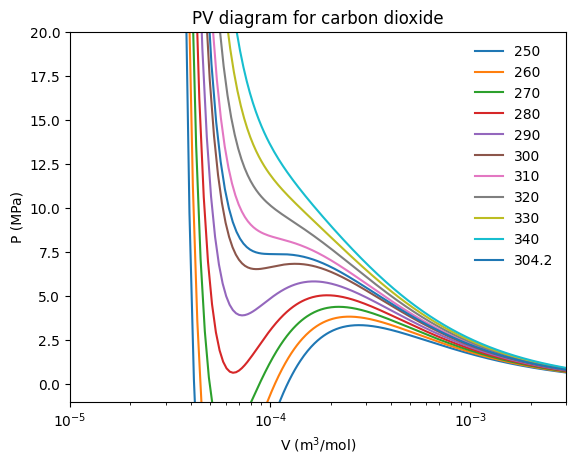

In [2]:
import matplotlib.pyplot as plt

# Critical values for carbon dioxide and the acentric factor
Pc = 7.376*10**6 # critical pressure in Pa
Tc = 304.2 # critical temperature in K
omega = 0.225 # acentric factor

fig, ax = plt.subplots()

# plot several isotherms
# use the same color for IG and vdW EOS
for T in range(250, 350, 10) : 
    V_max = constants.R*T/(100*1000)
    V_min = constants.R*T/(1000*1000)*0.015
    V = np.linspace(V_min,V_max,10000)

    ax.plot(V, PR_pressure(V,T,Pc,Tc,omega)/1e6, '-',label=T)

ax.plot(V, PR_pressure(V,Tc,Pc,Tc,omega)/1e6, '-',label=Tc)

ax.legend(frameon=True, fancybox=True, edgecolor='none')
ax.set_xscale('log')
plt.ylim([-1,20])
plt.xlim([1*10**-5,0.003])
plt.xlabel('V (m$^3$/mol)')
plt.ylabel('P (MPa)')
plt.title('PV diagram for carbon dioxide')

Our second example makes a prettier plot using Seaborn...

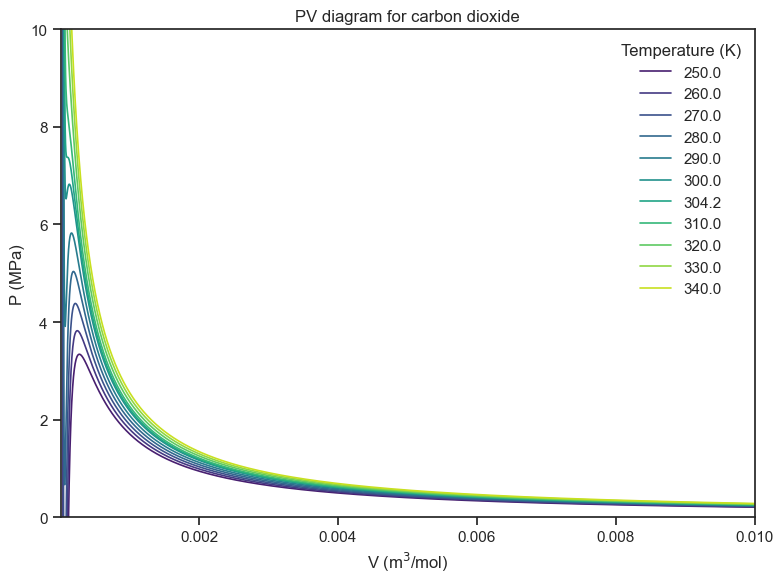

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import constants

# Critical values for carbon dioxide and the acentric factor
Pc = 7.376*10**6
Tc = 304.2
omega = 0.225

rows = []

# Make a list of temperatures for the isotherms and add Tc
temps = list(range(250, 350, 10))
temps.append(Tc)
temps = sorted(temps)

# Generate all isotherms including Tc
for T in temps:
    V_max = constants.R*T/(100*1000)
    V_min = constants.R*T/(1000*1000)*0.015
    V = np.linspace(V_min, V_max, 5000)
    P = PR_pressure(V, T, Pc, Tc, omega)/1e6
    
    rows.append(pd.DataFrame({
        "V": V,
        "P": P,
        "T": T
    }))

df = pd.concat(rows, ignore_index=True)

# Convert T to string for categorical hue (fixes legend)
df["T"] = df["T"].astype(str)

sns.set_theme(style="ticks")

fig, ax = plt.subplots(figsize=(8, 6))

sns.lineplot(
    data=df,
    x="V", y="P",
    hue="T",
    palette="viridis",
    linewidth=1.2,
    ax=ax
)

ax.set_xscale("log")
ax.set_ylim([0, 10])
ax.set_xlim([1e-5, 1e-2])

ax.set_xlabel("V (m$^3$/mol)")
ax.set_ylabel("P (MPa)")
ax.set_title("PV diagram for carbon dioxide")

# Remove legend box
leg = ax.legend(title="Temperature (K)", frameon=False)

plt.tight_layout()
plt.show()